In [1]:
import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/ring_full.csv")

In [3]:
df.head(5)

,green1,green2,ir1,ir2,Datetime,motion,motion_300
0,8715406.0,8502910.0,9946705.0,9762970.0,2026-06-10 11:31:23,2091,0
1,8716251.0,8503157.0,9947373.0,9763589.0,2026-06-10 11:31:23,2078,0
2,8715944.0,8503201.0,9947881.0,9763737.0,2026-06-10 11:31:23,2011,0
3,8715814.0,8503174.0,9948173.0,9764195.0,2026-06-10 11:31:23,1995,0
4,8715142.0,8503446.0,9948311.0,9764283.0,2026-06-10 11:31:23,1990,0


In [ ]:
df

原始数据量: 8262961 行 | 实际绘图数据量: 10004 行 (步长=826)


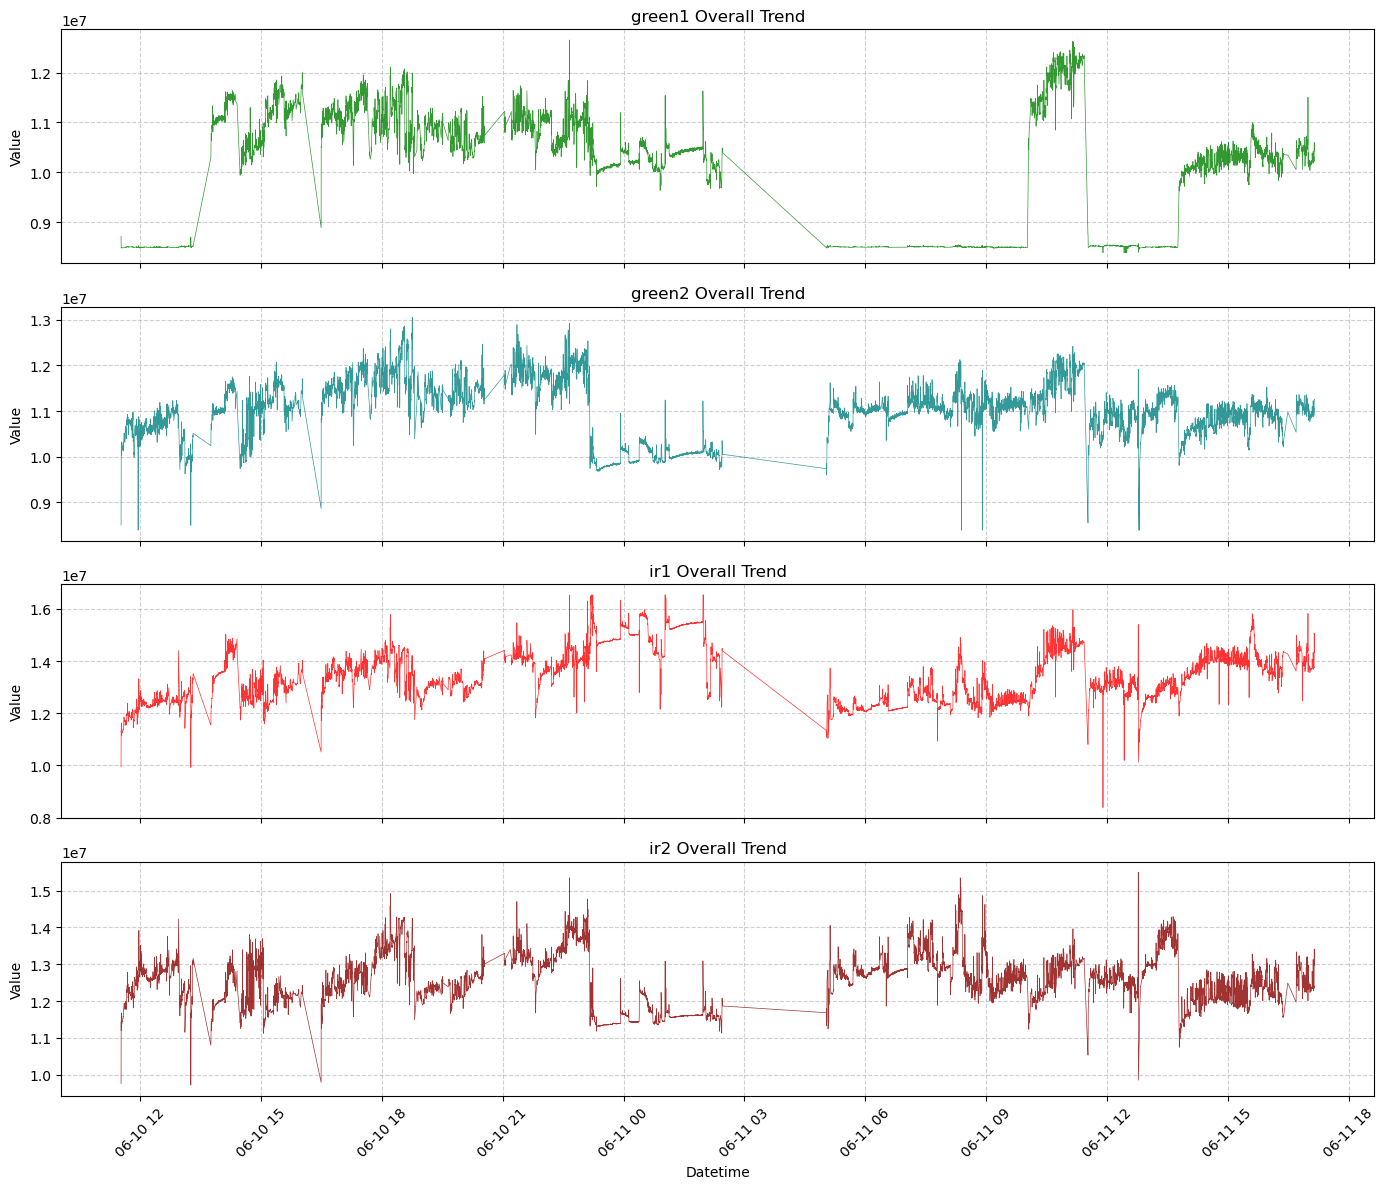

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 确保 Datetime 列是时间格式（如果已经是，这一步很快）
# 注意：800万行转换时间格式可能需要几秒钟
df['Datetime'] = pd.to_datetime(df['Datetime'])

# ---------------- 核心防卡顿逻辑 ----------------
# 强制限制每张图最多只画 10,000 个点
MAX_POINTS = 10000
total_rows = len(df)

# 计算步长：如果数据量大于 1万，就每隔 step 行取一条数据
step = total_rows // MAX_POINTS if total_rows > MAX_POINTS else 1

# 获取降采样后的数据（这个切片操作在 Pandas 里是瞬间完成的）
df_plot = df.iloc[::step]
print(f"原始数据量: {total_rows} 行 | 实际绘图数据量: {len(df_plot)} 行 (步长={step})")
# ------------------------------------------------

# 创建 4行1列 的子图，高度设为 12 保证充足的显示空间
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

# 定义要画的列和对应的颜色
columns_to_plot = ['green1', 'green2', 'ir1', 'ir2']
colors = ['green', 'teal', 'red', 'darkred']

# 使用循环遍历绘制 4 张子图，代码更简洁
for i, col in enumerate(columns_to_plot):
    # 使用降采样后的 df_plot 进行绘图
    axes[i].plot(df_plot['Datetime'], df_plot[col], color=colors[i], linewidth=0.5, alpha=0.8)
    axes[i].set_title(f'{col} Overall Trend')
    axes[i].set_ylabel('Value')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 只在最底层子图设置 X 轴标签并旋转刻度
axes[3].set_xlabel('Datetime')
plt.xticks(rotation=45)

# 紧凑布局，防止标签重叠
plt.tight_layout()

# 显示图表
plt.show()

In [5]:
df.head(5)

,green1,green2,ir1,ir2,Datetime,motion,motion_300
0,8715406.0,8502910.0,9946705.0,9762970.0,2026-06-10 11:31:23,2091,0
1,8716251.0,8503157.0,9947373.0,9763589.0,2026-06-10 11:31:23,2078,0
2,8715944.0,8503201.0,9947881.0,9763737.0,2026-06-10 11:31:23,2011,0
3,8715814.0,8503174.0,9948173.0,9764195.0,2026-06-10 11:31:23,1995,0
4,8715142.0,8503446.0,9948311.0,9764283.0,2026-06-10 11:31:23,1990,0


In [6]:
df['green2'].to_csv("green2.txt", index=False)

In [22]:
x = df["ir2"].iloc[5000:6000].to_numpy()

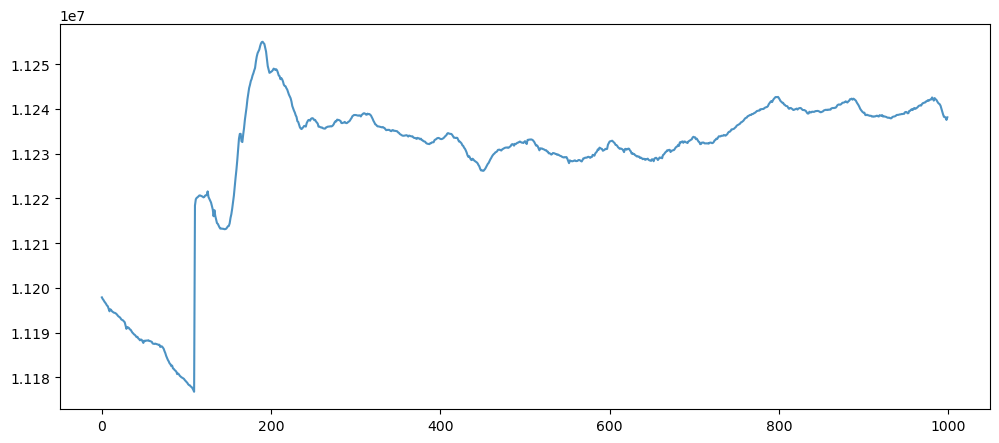

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(x, alpha=0.8)
plt.show()